<a href="https://colab.research.google.com/github/Mehtabwho/CSE-Lab-Courses/blob/main/8th_sem%20/DM_LAB%20/Recommendation_System_1068.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Import Libraries**

In [1]:
# IMPORT REQUIRED LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning and Metrics utilities
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# For interactive UI Widget elements
import ipywidgets as widgets
from IPython.display import display, clear_output

# Set visual styles for plots
sns.set_theme(style="whitegrid")
%matplotlib inline

## **Load Datasets**

In [2]:
# LOAD DATASETS
from google.colab import drive
drive.mount('/content/drive')
try:
    ratings_raw = pd.read_csv("/content/drive/MyDrive/DM_LAB/Ratings.csv")
    movies_raw = pd.read_csv("/content/drive/MyDrive/DM_LAB/movies.csv")
    print(f"Successfully loaded {ratings_raw.shape[0]} ratings and {movies_raw.shape[0]} movies.")
except FileNotFoundError:
    print("Error: Please verify your Drive file path locations.")

Mounted at /content/drive
Successfully loaded 100836 ratings and 9742 movies.


## **Data Preprocessing & Exploratory Analytics**

In [3]:
# DATA PREPROCESSING & EXPLORATION

# Merge datasets on the common key 'movieId' to have titles alongside ratings
data_merged = pd.merge(ratings_raw, movies_raw, on='movieId')

print("--- Cleaned Merged Dataset Sample ---")
display(data_merged.head())

user_item_matrix = data_merged.pivot_table(index='userId', columns='movieId', values='rating')

# Handle missing values: Fill NaNs with 0 to denote unrated items for matrix operations
user_item_matrix_filled = user_item_matrix.fillna(0)

print(f"\nUser-Item Matrix Dimensions: {user_item_matrix_filled.shape[0]} Users x {user_item_matrix_filled.shape[1]} Movies")

--- Cleaned Merged Dataset Sample ---


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller



User-Item Matrix Dimensions: 610 Users x 9724 Movies


/tmp/ipykernel_571/1960178942.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=ratings_raw, ax=axes[0], palette='viridis')
/tmp/ipykernel_571/1960178942.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_movies.values, y=top_movies.index, ax=axes[1], palette='magma')


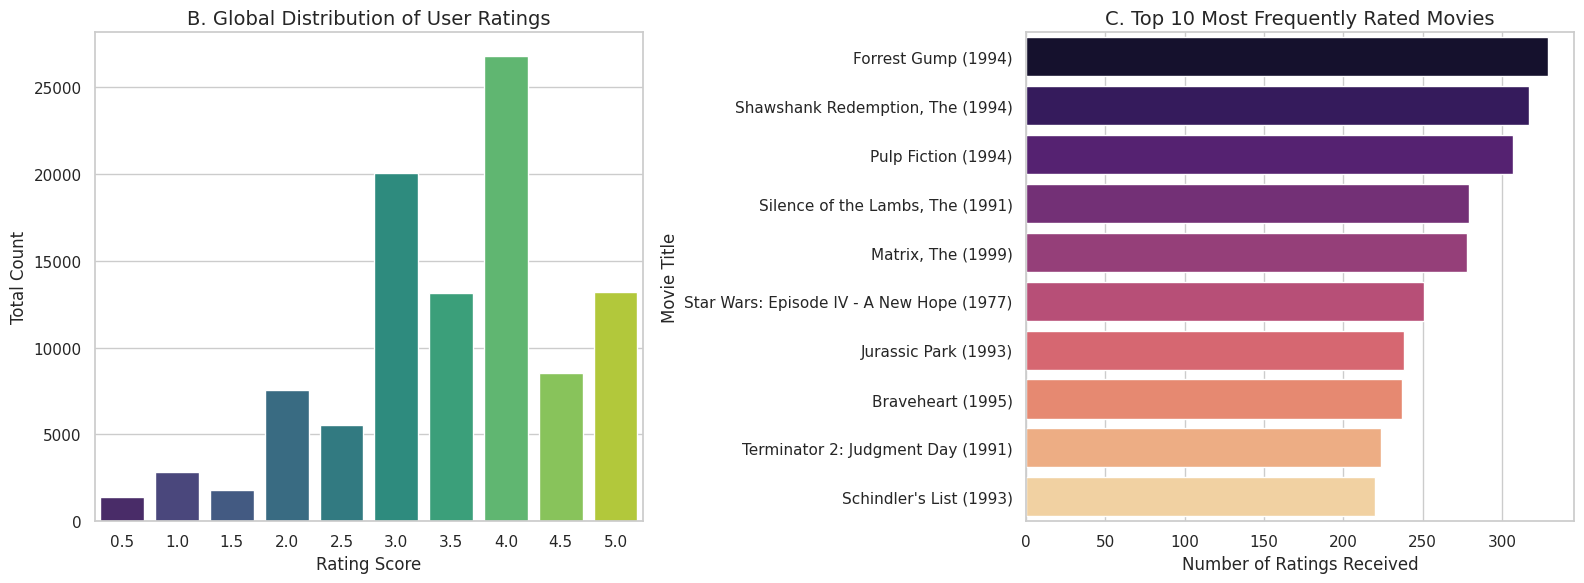

In [4]:
# VISUALIZATIONS
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Visualization B: Distribution of Ratings
sns.countplot(x='rating', data=ratings_raw, ax=axes[0], palette='viridis')
axes[0].set_title('B. Global Distribution of User Ratings', fontsize=14)
axes[0].set_xlabel('Rating Score')
axes[0].set_ylabel('Total Count')

# Visualization C: Top Rated/Most Watched Movies
top_movies = data_merged.groupby('title')['rating'].count().sort_values(ascending=False).head(10)
sns.barplot(x=top_movies.values, y=top_movies.index, ax=axes[1], palette='magma')
axes[1].set_title('C. Top 10 Most Frequently Rated Movies', fontsize=14)
axes[1].set_xlabel('Number of Ratings Received')
axes[1].set_ylabel('Movie Title')

plt.tight_layout()
plt.show()

## **Compute Item Similarity Matrix**

In [5]:
# COMPUTE ITEM SIMILARITY (COSINE)

item_user_matrix = user_item_matrix_filled.T

# Compute pairwise cosine similarities across all items
item_similarity_scores = cosine_similarity(item_user_matrix)

# Wrap array into a clean DataFrame structured with Movie IDs as index & columns
item_sim_df = pd.DataFrame(item_similarity_scores,
                             index=user_item_matrix_filled.columns,
                             columns=user_item_matrix_filled.columns)

print("Item-Item Similarity Matrix created successfully.")
display(item_sim_df.iloc[:5, :5]) # Sample matrix snapshot

Item-Item Similarity Matrix created successfully.


movieId,1,2,3,4,5
movieId,,,,,
1,1.000000,0.410562,0.296917,0.035573,0.308762
2,0.410562,1.000000,0.282438,0.106415,0.287795
3,0.296917,0.282438,1.000000,0.092406,0.417802
4,0.035573,0.106415,0.092406,1.000000,0.188376
5,0.308762,0.287795,0.417802,0.188376,1.000000


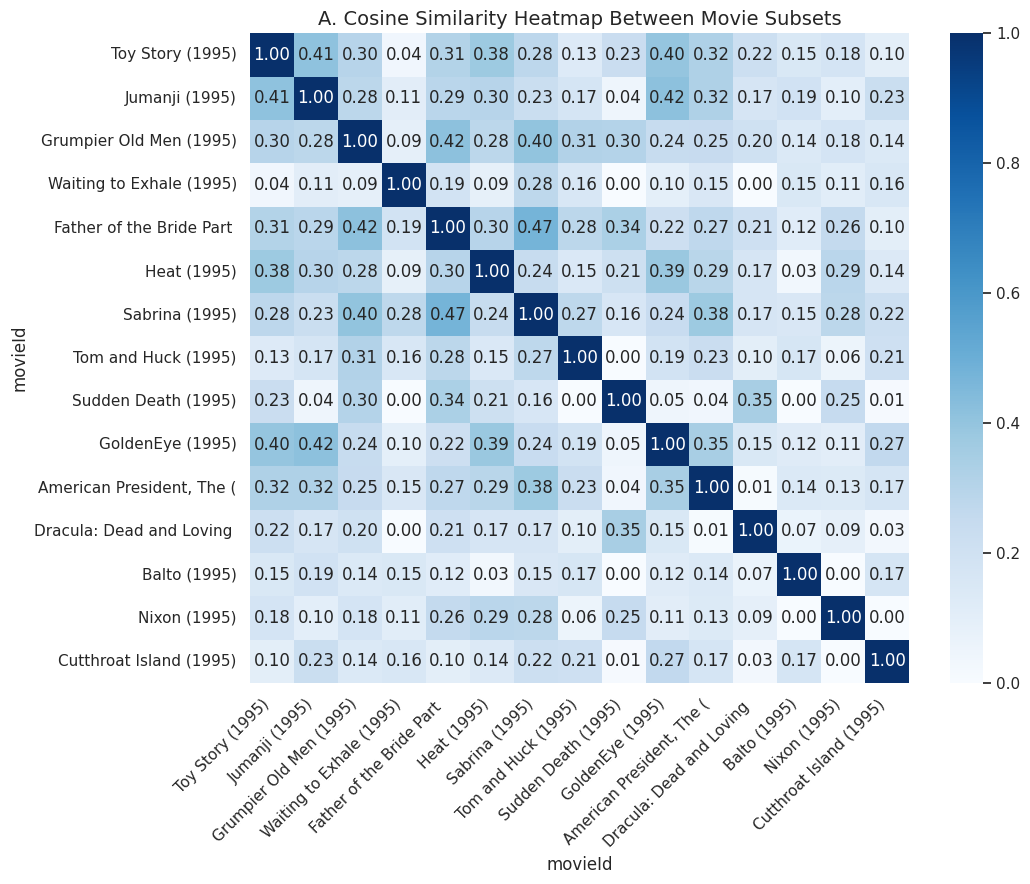

In [6]:
# VISUALIZATION A: ITEM SIMILARITY HEATMAP
plt.figsize=(10, 8)

# Isolate a small subset of movies (first 15 columns) for readability
subset_movie_ids = item_sim_df.columns[:15]
subset_titles = [movies_raw[movies_raw['movieId'] == m_id]['title'].values[0][:25] for m_id in subset_movie_ids]

plt.figure(figsize=(11, 9))
sns.heatmap(item_sim_df.loc[subset_movie_ids, subset_movie_ids],
            xticklabels=subset_titles,
            yticklabels=subset_titles,
            annot=True,
            cmap='Blues',
            fmt=".2f",
            cbar=True)

plt.title('A. Cosine Similarity Heatmap Between Movie Subsets', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## **Recommendation Engine Implementation**

In [7]:
# PREDICT PREFERENCES & GENERATE RECOMMENDATIONS

def get_recommendations(user_id, top_n=10):
    """
    Identifies watched movies, calculates preference weights for unwatched items
    using similarity dot products, and outputs top-N suggestions.
    """
    if user_id not in user_item_matrix.index:
        return f"User ID {user_id} does not exist in the database.", None

    # Isolate real ratings from original matrix (keeping NaNs intact)
    user_ratings = user_item_matrix.loc[user_id]

    # Track items the user has explicitly touched
    watched_movies = user_ratings.dropna().index.tolist()
    unwatched_movies = user_ratings[user_ratings.isna()].index.tolist()

    predicted_scores = {}

    # Loop over unrated movies to generate predicted preference scores
    for target_movie in unwatched_movies:
        # Get cosine values between target item and all other items
        sim_scores = item_sim_df[target_movie]

        # Pull only items the target user actually rated
        valid_scores = sim_scores[watched_movies]
        actual_ratings = user_ratings[watched_movies]

        # Compute Weighted Average: Sum(Similarity * Rating) / Sum(Similarity)
        # Avoid division errors if similarities sum to 0
        sum_sim = valid_scores.sum()
        if sum_sim > 0:
            predicted_scores[target_movie] = np.dot(valid_scores, actual_ratings) / sum_sim
        else:
            predicted_scores[target_movie] = 0

    # Compile results and sort descending by score
    rec_series = pd.Series(predicted_scores).sort_values(ascending=False).head(top_n)

    # Map raw structural indices back to titles
    recommendation_output = []
    for m_id, score in rec_series.items():
        title = movies_raw[movies_raw['movieId'] == m_id]['title'].values[0]
        recommendation_output.append({'Movie Title': title, 'Predicted Score': round(score, 2)})

    # Format user's historically liked movies for presentation display
    history_list = []
    top_history = user_ratings.dropna().sort_values(ascending=False).head(5)
    for m_id, rating in top_history.items():
        title = movies_raw[movies_raw['movieId'] == m_id]['title'].values[0]
        history_list.append({'Movie Title': title, 'Your Rating': rating})

    return pd.DataFrame(history_list), pd.DataFrame(recommendation_output)

In [8]:
# SAMPLE EVALUATION RUN: GENERATE RECOMMENDATIONS FOR 5 USERS

# Grab 5 valid user IDs dynamically from the dataset
sample_users = user_item_matrix.index[:5].tolist()

for uid in sample_users:
    print("\n" + "="*60)
    print(f" SYSTEM METRICS PROFILE FOR USER ID: {uid}")
    print("="*60)

    history_df, rec_df = get_recommendations(user_id=uid, top_n=5)

    print("\n[User's Top Historically Rated Movies]")
    display(history_df)

    print("\n[Engine Calculated Top Recommendations]")
    display(rec_df)


 SYSTEM METRICS PROFILE FOR USER ID: 1

[User's Top Historically Rated Movies]


,Movie Title,Your Rating
0,Seven (a.k.a. Se7en) (1995),5.0
1,"Usual Suspects, The (1995)",5.0
2,Bottle Rocket (1996),5.0
3,Dumb & Dumber (Dumb and Dumber) (1994),5.0
4,Billy Madison (1995),5.0



[Engine Calculated Top Recommendations]


,Movie Title,Predicted Score
0,The Stanford Prison Experiment (2015),5.0
1,Bungo Stray Dogs: Dead Apple (2018),5.0
2,Black Butler: Book of the Atlantic (2017),5.0
3,Gintama (2017),5.0
4,The Clapper (2018),5.0



 SYSTEM METRICS PROFILE FOR USER ID: 2

[User's Top Historically Rated Movies]


...

,Movie Title,Predicted Score
0,Alien Contamination (1980),5.0
1,Looker (1981),5.0
2,Galaxy of Terror (Quest) (1981),5.0
3,"Jungle Book 2, The (2003)",5.0
4,Come See the Paradise (1990),5.0



 SYSTEM METRICS PROFILE FOR USER ID: 5

[User's Top Historically Rated Movies]


,Movie Title,Your Rating
0,Heavenly Creatures (1994),5.0
1,"Postman, The (Postino, Il) (1994)",5.0
2,Once Were Warriors (1994),5.0
3,Pulp Fiction (1994),5.0
4,In the Name of the Father (1993),5.0



[Engine Calculated Top Recommendations]


,Movie Title,Predicted Score
0,Amer (2009),5.0
1,Addams Family Reunion (1998),5.0
2,This Property is Condemned (1966),5.0
3,Trippin' (1999),5.0
4,Dancemaker (1998),5.0


### Explanation of Recommendation Generation

This system uses Item-Based Collaborative Filtering.

1.  Item Similarity: It first calculates how similar movies are to each other based on how users have rated them (using cosine similarity on a user-item matrix).
2. Rating Prediction: For a user (or given preferences), it identifies movies they've rated. To predict a rating for an unrated movie, it takes a weighted average of the user's ratings for similar movies. The 'weight' is the similarity score between the unrated movie and the rated movies.
3.  Recommendation: The movies with the highest predicted ratings for the user are then recommended.

## **Evaluation**

In [9]:
# STEP 7: PERFORMANCE EVALUATION (MAE & PRECISION@K)
print("Executing System Performance Diagnostics... (Please wait)")

# 1. Split interactions into Train and Test pools (80/20)
train_data, test_data = train_test_split(ratings_raw, test_size=0.2, random_state=42)

# 2. Build internal Train Interaction Matrix for validation
train_pivot = train_data.pivot_table(index='userId', columns='movieId', values='rating').fillna(0)
train_item_sim = cosine_similarity(train_pivot.T)
train_sim_df = pd.DataFrame(train_item_sim, index=train_pivot.columns, columns=train_pivot.columns)

# 3. Track performance tracking lists
absolute_errors = []
precision_at_k_list = []
k = 10

# Sample 30 users to evaluate efficiency smoothly without timing out
test_users = test_data['userId'].unique()[:30]

for user in test_users:
    user_test_ratings = test_data[test_data['userId'] == user]
    user_train_ratings = train_pivot.loc[user] if user in train_pivot.index else pd.Series(0, index=train_pivot.columns)

    watched_indices = user_train_ratings[user_train_ratings > 0].index.tolist()

    preds = {}
    for _, row in user_test_ratings.iterrows():
        m_id = row['movieId']
        actual = row['rating']

        if m_id in train_sim_df.columns and len(watched_indices) > 0:
            sims = train_sim_df.loc[m_id, watched_indices]
            ratings = user_train_ratings[watched_indices]

            if sims.sum() > 0:
                pred = np.dot(sims, ratings) / sims.sum()
                absolute_errors.append(abs(actual - pred))
                preds[m_id] = pred

    # Calculate Precision@K: Ratio of recommended items that match a high ground-truth rating (>3.5)
    if len(preds) > 0:
        sorted_preds = sorted(preds.items(), key=lambda x: x[1], reverse=True)[:k]
        hits = sum(1 for m_id, _ in sorted_preds if user_test_ratings[user_test_ratings['movieId'] == m_id]['rating'].values[0] >= 3.5)
        precision_at_k_list.append(hits / min(k, len(preds)))

# Calculate final aggregated metrics
final_mae = np.mean(absolute_errors)
final_precision = np.mean(precision_at_k_list) if precision_at_k_list else 0.0

print("SYSTEM EVALUATION METRICS")
print(f"Mean Absolute Error (MAE): {final_mae:.4f}")
print(f"System Precision@{k}      : {final_precision * 100:.2f}%")

Executing System Performance Diagnostics... (Please wait)
SYSTEM EVALUATION METRICS
Mean Absolute Error (MAE): 0.7111
System Precision@10      : 75.24%


The evaluation results show that the recommendation system performs quite well. The MAE value of 0.7111 indicates that the difference between predicted and actual ratings is relatively low. Additionally, the 75.24% Precision@10 score shows that most of the recommended movies matched the users' interests. This suggests that the Item-Based Collaborative Filtering approach is effective in providing relevant and personalized movie recommendations.

In [10]:
# INTERACTIVE INTERFACE

# Widgets for inputting preferences
movie_search_input = widgets.Text(description="Movie Title:")
search_movie_button = widgets.Button(description="Search Movie", button_style='info')
search_results_output = widgets.Output()

selected_movie_dropdown = widgets.Dropdown(description="Select Movie:", options=[])
rating_slider = widgets.FloatSlider(value=3.5, min=0.5, max=5.0, step=0.5, description="Your Rating:")
add_preference_button = widgets.Button(description="Add Preference", button_style='primary')
current_preferences_output = widgets.Output()
get_custom_recs_button = widgets.Button(description="Get Custom Recommendations", button_style='success')
custom_recs_output = widgets.Output()

user_preferences = [] # Store movie_id and rating

def search_movie_handler(b):
    with search_results_output:
        clear_output()
        search_term = movie_search_input.value
        if search_term:
            # Case-insensitive search
            matching_movies = movies_raw[movies_raw['title'].str.contains(search_term, case=False, na=False)]
            if not matching_movies.empty:
                # Display top 5 matches
                # Ensure that all movieIds exist as columns in item_sim_df
                matching_movies_filtered = matching_movies[matching_movies['movieId'].isin(item_sim_df.columns)]
                options = [(f"{row['title']} (ID: {row['movieId']})", row['movieId']) for _, row in matching_movies_filtered.head(5).iterrows()]
                selected_movie_dropdown.options = options
                if options:
                    selected_movie_dropdown.value = options[0][1] # Pre-select first option
                print(f"Found {len(matching_movies_filtered)} matches. Showing top {min(5, len(matching_movies_filtered))}.")
            else:
                selected_movie_dropdown.options = []
                selected_movie_dropdown.value = None
                print("No movies found matching your search or available for recommendations.")
        else:
            selected_movie_dropdown.options = []
            selected_movie_dropdown.value = None
            print("Please enter a movie title to search.")

def add_preference_handler(b):
    with current_preferences_output:
        clear_output()
        if selected_movie_dropdown.value is not None:
            movie_id = selected_movie_dropdown.value
            rating = rating_slider.value
            # Update existing preference or add new one
            updated = False
            for i, pref in enumerate(user_preferences):
                if pref['movieId'] == movie_id:
                    user_preferences[i]['rating'] = rating
                    updated = True
                    print(f"Updated rating for: {selected_movie_dropdown.label.split(' (ID:')[0]} to {rating}")
                    break
            if not updated:
                user_preferences.append({'movieId': movie_id, 'rating': rating})
                print(f"Added: {selected_movie_dropdown.label.split(' (ID:')[0]} with rating {rating}")
        else:
            print("No movie selected to add preference.")
        display_current_preferences()

def display_current_preferences():
    with current_preferences_output:
        clear_output()
        if user_preferences:
            print("Your current preferences:")
            pref_df = pd.DataFrame(user_preferences)
            pref_df['title'] = pref_df['movieId'].apply(lambda x: movies_raw[movies_raw['movieId'] == x]['title'].values[0] if x in movies_raw['movieId'].values else f"Movie ID {x}")
            display(pref_df[['title', 'rating']])
        else:
            print("No preferences added yet.")

def get_recommendations_custom_prefs(user_prefs_list, top_n=10):
    if not user_prefs_list:
        return pd.DataFrame(), pd.DataFrame()

    # Create a temporary user_ratings Series from the provided preferences
    temp_user_ratings_data = {p['movieId']: p['rating'] for p in user_prefs_list if p['movieId'] in item_sim_df.columns}

    if not temp_user_ratings_data:
        return "None of the preferred movies are in our database for similarity calculation.", None

    temp_user_ratings = pd.Series(temp_user_ratings_data)

    # All movie IDs in the system from the similarity matrix
    all_movie_ids = item_sim_df.columns

    # Items the user has explicitly rated (from preferences)
    watched_movies = temp_user_ratings.index.tolist()

    # Items the user has NOT rated but exist in the system (and in similarity matrix)
    unwatched_movies = [m_id for m_id in all_movie_ids if m_id not in watched_movies]

    predicted_scores = {}

    for target_movie in unwatched_movies:
        # Ensure target movie exists in similarity matrix columns
        if target_movie in item_sim_df.columns:
            sim_scores = item_sim_df[target_movie]

            # Pull only items the target user actually rated from their preferences
            # and make sure they also have similarity scores with the target movie
            valid_sim_scores_for_watched = sim_scores.reindex(watched_movies).dropna()
            actual_ratings_for_watched = temp_user_ratings.reindex(valid_sim_scores_for_watched.index).dropna()

            # Ensure there are valid items to calculate similarity
            if not valid_sim_scores_for_watched.empty:
                sum_sim = valid_sim_scores_for_watched.sum()
                if sum_sim > 0:
                    predicted_scores[target_movie] = np.dot(valid_sim_scores_for_watched, actual_ratings_for_watched) / sum_sim
                else:
                    predicted_scores[target_movie] = 0
            else:
                predicted_scores[target_movie] = 0
        else:
            predicted_scores[target_movie] = 0 # Cannot recommend if target movie not in sim matrix

    rec_series = pd.Series(predicted_scores).sort_values(ascending=False).head(top_n)

    recommendation_output = []
    for m_id, score in rec_series.items():
        title = movies_raw[movies_raw['movieId'] == m_id]['title'].values[0] if m_id in movies_raw['movieId'].values else f"Movie ID {m_id}"
        recommendation_output.append({'Movie Title': title, 'Predicted Score': round(score, 2)})

    # History for custom prefs will be the preferences they entered
    history_list = []
    for p in user_prefs_list:
        title = movies_raw[movies_raw['movieId'] == p['movieId']]['title'].values[0] if p['movieId'] in movies_raw['movieId'].values else f"Movie ID {p['movieId']}"
        history_list.append({'Movie Title': title, 'Your Rating': p['rating']})

    return pd.DataFrame(history_list), pd.DataFrame(recommendation_output)


def get_custom_recs_handler(b):
    with custom_recs_output:
        clear_output()
        print("Generating recommendations based on your preferences...\n")
        history_df, rec_df = get_recommendations_custom_prefs(user_preferences, top_n=10)

        if isinstance(history_df, str): # Handle the error message case
             print(history_df)
        elif history_df.empty and rec_df.empty:
            print("Please add some movie preferences to get recommendations.")
        else:
            print(" Your Custom Preferences:")
            display(history_df)
            print("\n Top 10 Personalized Movie Recommendations for You:")
            display(rec_df)

sim_score_button = widgets.Button(description="Get Recommendations", button_style='success', icon='check')
search_movie_button.on_click(search_movie_handler)
add_preference_button.on_click(add_preference_handler)
sim_score_button.on_click(get_custom_recs_handler)

# Initial display of current preferences
display_current_preferences()

# Layout for the new feature
new_feature_layout = widgets.VBox([
    widgets.Label("--- Get Recommendations by Your Preferences ---"),
    widgets.HBox([movie_search_input, search_movie_button]),
    search_results_output,
    widgets.HBox([selected_movie_dropdown, rating_slider, add_preference_button]),
    current_preferences_output,
    sim_score_button,
    custom_recs_output
])

# Layout Presentation (Combine existing and new)
display(new_feature_layout)
